In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Telco Customer Churn Prediction

This notebook documents the process of building a classification model to predict customer churn for a telecommunications company.

## 1. Data Loading and Initial Exploration

The first step involves loading the dataset and performing an initial inspection to understand its structure, data types, and identify potential issues like missing values.

In [5]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display initial information
print("Data Shape:", df.shape)
print("\nData Types and Non-Null Counts:")
df.info()

print("\nFirst 5 rows:")
print(df.head())

Data Shape: (7043, 21)

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerID         7043 non-null   object 
 1   gender             7043 non-null   object 
 2   Senior_Citizen     7043 non-null   int64  
 3   Is_Married         7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   Phone_Service      7043 non-null   object 
 7   Dual               7043 non-null   object 
 8   Internet_Service   7043 non-null   object 
 9   Online_Security    7043 non-null   object 
 10  Online_Backup      7043 non-null   object 
 11  Device_Protection  7043 non-null   object 
 12  Tech_Support       7043 non-null   object 
 13  Streaming_TV       7043 non-null   object 
 14  Streaming_Movies   7043 non-null   object 
 15  Contract        

In [6]:
print("\data info for data types and null count:")
print(df.info())

\data info for data types and null count:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerID         7043 non-null   object 
 1   gender             7043 non-null   object 
 2   Senior_Citizen     7043 non-null   int64  
 3   Is_Married         7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   Phone_Service      7043 non-null   object 
 7   Dual               7043 non-null   object 
 8   Internet_Service   7043 non-null   object 
 9   Online_Security    7043 non-null   object 
 10  Online_Backup      7043 non-null   object 
 11  Device_Protection  7043 non-null   object 
 12  Tech_Support       7043 non-null   object 
 13  Streaming_TV       7043 non-null   object 
 14  Streaming_Movies   7043 non-null   object 
 15  Contract           7043 non-nu

## 2. Data Preprocessing

This section covers the steps taken to clean and transform the data for model training, including:

- Handling missing values.
- Converting categorical features into numerical representations using techniques like Label Encoding and One-Hot Encoding.
- Scaling numerical features to ensure they contribute equally to the model.

In [7]:
# Convert Total_Charges to numeric, handling non-numeric entries (likely spaces)
df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')

# Check for missing values in Total_Charges
missing_total_charges = df['Total_Charges'].isnull().sum()
print(f"\nNumber of missing values in Total_Charges: {missing_total_charges}")

# For a small number of missing values (if any), a good imputation strategy is to replace
# them with the median, especially since these cases often correspond to customers with 0 tenure.

# Customers with 0 tenure likely just signed up, so their Total_Charges should be close to Monthly_Charges.

# However, for simplicity, I will fill with the median for now, or drop them if the count is very low.
# Given the context (Telco Churn), these are likely new customers, so imputing with the median is safer than dropping.

df['Total_Charges'].fillna(df['Total_Charges'].median(), inplace=True)
print("Missing Total_Charges handled by median imputation.")


Number of missing values in Total_Charges: 11
Missing Total_Charges handled by median imputation.


C:\Users\moham\AppData\Local\Temp\ipykernel_4104\1289335074.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total_Charges'].fillna(df['Total_Charges'].median(), inplace=True)


For the column Churn, I found that the calculation of its value counts using normalize=True immediately provides the vital information about class distribution. The output confirms a significant class imbalance: roughly 73.5% of the observations are in the 'No' class, while the target minority class ('Yes' or churn) accounts for only about 26.5%. This initial analysis is crucial, as it sets the stage for future modeling decisions, such as the potential use of class weighting or focusing on metrics like Recall and F1-Score over simple Accuracy.

In [8]:
# Convert 'Churn' to a binary numeric column (0 and 1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
churn_counts = df['Churn'].value_counts(normalize=True) * 100

print("\nChurn Distribution:")
print(churn_counts)

# Visualization shows a significant class imbalance: ~73.5% 'No', ~26.5% 'Yes' Goal is to find patterns that predict the minority class (churn).


Churn Distribution:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


Describing the numerical features to look for anything out of the ordinary

In [9]:
numerical_cols = ['tenure', 'Monthly_Charges', 'Total_Charges']
print("\nNumerical Feature Statistics:")
print(df[numerical_cols].describe())


Numerical Feature Statistics:
            tenure  Monthly_Charges  Total_Charges
count  7043.000000      7043.000000    7043.000000
mean     32.371149        64.761692    2281.916928
std      24.559481        30.090047    2265.270398
min       0.000000        18.250000      18.800000
25%       9.000000        35.500000     402.225000
50%      29.000000        70.350000    1397.475000
75%      55.000000        89.850000    3786.600000
max      72.000000       118.750000    8684.800000


Text(0, 0.5, 'Frequency')

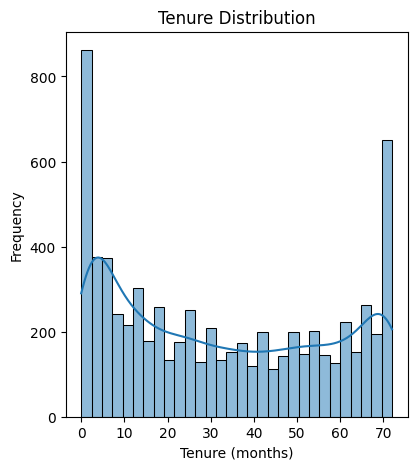

In [10]:
# 1. tenure: Bimodal distribution, with peaks at very low and very high values
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title('Tenure Distribution')
plt.xlabel('Tenure (months)')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

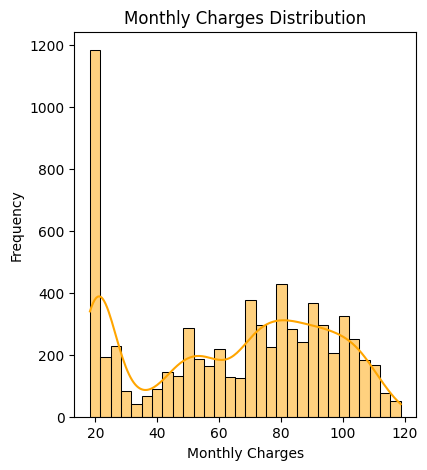

In [11]:
# 2. Monthly_Charges: Skewed towards lower values, but also a cluster around high values (Fiber Optic users).
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 2)
sns.histplot(df['Monthly_Charges'], bins=30, kde=True, color='orange')
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')

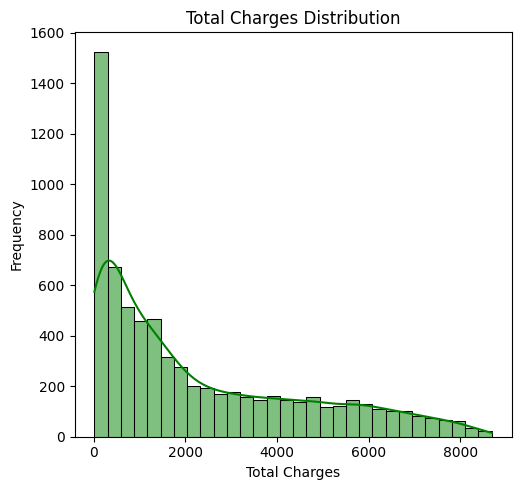

In [12]:
# 3. Total_Charges: Highly skewed, as expected, since it's cumulative.
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 3)
sns.histplot(df['Total_Charges'], bins=30, kde=True, color='green')
plt.title('Total Charges Distribution')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


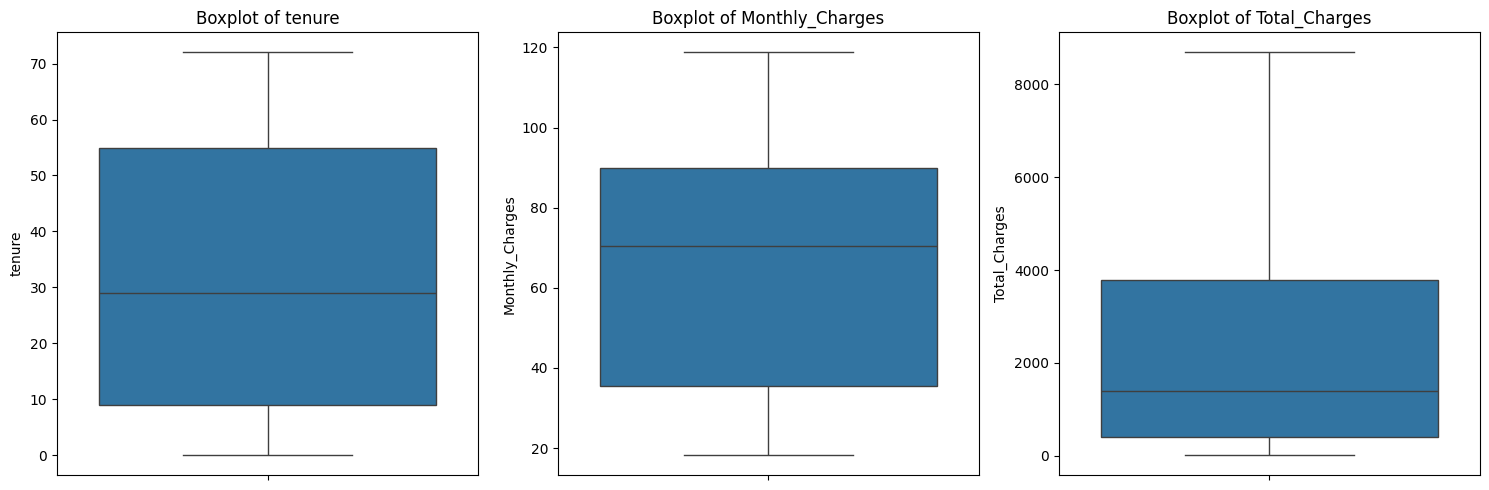

In [13]:
# No severe outliers are apparent that would require aggressive clipping, but scaling is essential.
# boxplot for numerical features
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [14]:
# Identify categorical columns (excluding 'customerID' and numeric ones)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("\nUnique values in key categorical columns:")
for col in ['gender', 'Dependents', 'Phone_Service', 'Internet_Service', 'Contract']:
    print(f"  {col}: {df[col].unique()}")


Unique values in key categorical columns:
  gender: ['Female' 'Male']
  Dependents: ['No' 'Yes']
  Phone_Service: ['No' 'Yes']
  Internet_Service: ['DSL' 'Fiber optic' 'No']
  Contract: ['Month-to-month' 'One year' 'Two year']


In [15]:
df.columns

Index(['customerID', 'gender', 'Senior_Citizen ', 'Is_Married', 'Dependents',
       'tenure', 'Phone_Service', 'Dual', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn'],
      dtype='object')

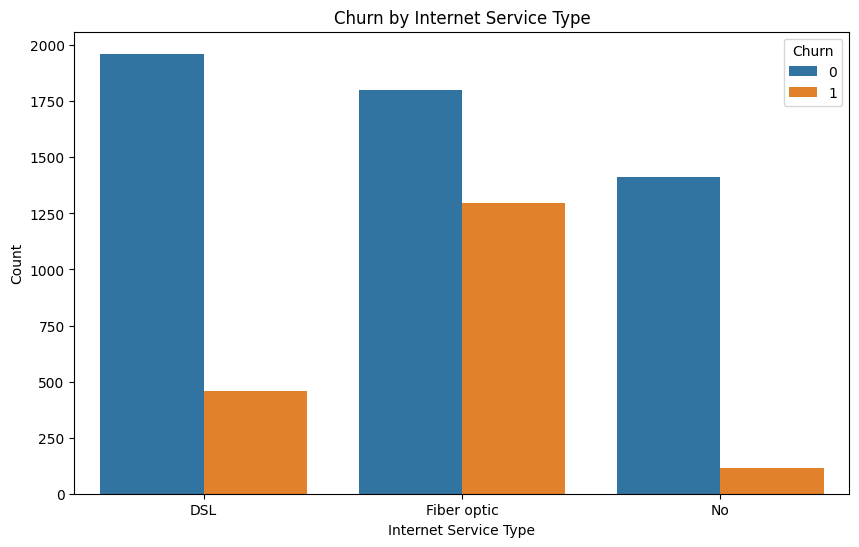

In [16]:
# Internet_Service: Fiber optic users churn significantly more.
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Internet_Service", hue='Churn')
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service Type')
plt.ylabel('Count')
plt.show()

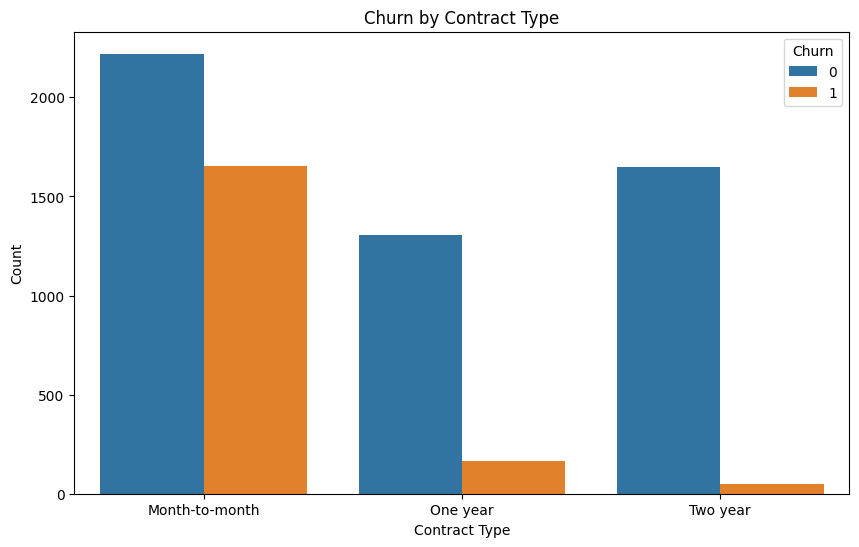

In [17]:
# Contract: Month-to-month has a much higher churn rate.
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

In [18]:
# Drop the identifier column
df.drop('customerID', axis=1, inplace=True)
print("\nDropped 'customerID'.")


Dropped 'customerID'.


In [19]:
print(df.columns.to_list())

['gender', 'Senior_Citizen ', 'Is_Married', 'Dependents', 'tenure', 'Phone_Service', 'Dual', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn']


**To solve the problem of inconsistent categorization and object data types**, I've employed a two-part strategy:

1.  **Category Consolidation (Cleaning):**  recognized that the values 'No phone service' and 'No internet service' are functionally equivalent to 'No' for the related service columns. And acted accordingly.

2.  **Binary Label Encoding:** identified columns that are binary (two states) and applied appropriate label encoding ($0$ and $1$).
    * For the `gender` column, the mapping `{'Female': 0, 'Male': 1}` is clean and explicit.
    * For the core service columns (listed in `binary_cols`), the loop applies the standard `{'No': 0, 'Yes': 1}` mapping. The check `if df[col].dtype == 'object'` is a good safeguard to prevent errors if any column had already been encoded.

**For the columns in question, I found that** this approach is highly efficient. By label-encoding these binary columns (rather than using one-hot encoding), you prevent an unnecessary explosion of features and keep the dimensionality low, and keeping out from the curse of dimensionality.

In [20]:
# Re-map 'No phone service' and 'No internet service' to 'No'
for col in df.columns:
    if 'No phone service' in df[col].unique():
        df[col] = df[col].replace('No phone service', 'No')
    if 'No internet service' in df[col].unique():
        df[col] = df[col].replace('No internet service', 'No')

# Label Encode binary columns (Yes/No and gender)
binary_cols = [
    'Is_Married', 'Dependents', 'Phone_Service', 'Paperless_Billing',
    'Dual', 'Online_Security', 'Online_Backup', 'Device_Protection',
    'Tech_Support', 'Streaming_TV', 'Streaming_Movies'
]
# For gender (Male/Female)
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

# For Yes/No columns
for col in binary_cols[2:]:
    # Ensure all are Yes/No before mapping (SeniorCitizen is already 0/1)
    if df[col].dtype == 'object':
        df[col] = df[col].map({'No': 0, 'Yes': 1})

print("\nBinary columns label-encoded (Yes/No to 1/0, Female/Male to 0/1).")


Binary columns label-encoded (Yes/No to 1/0, Female/Male to 0/1).


doinf the same for more columns that were not converted using the if dtype=='object' condition 

In [21]:
# change Dependents to 0/1
df['Dependents'] = df['Dependents'].map({'No': 0, 'Yes': 1})
df['Is_Married'] = df['Is_Married'].map({'No': 0, 'Yes': 1})

*To solve the problem of nominal categorical data types**
I have identified the columns (`Internet_Service`, `Contract`, `Payment_Method`) that have more than two unique, non-ordinal categories. Using `pd.get_dummies` for **One-Hot Encoding (OHE)** is the standard and correct procedure here.

Here I identify the numerical columns **(tenure, Monthly_Charges, Total_Charges)** that need standardization, create a StandardScaler to normalize them, fit and transform those columns in the dataset, and finally create a pipeline using all of these.

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# Columns
numerical_cols = ['tenure', 'Monthly_Charges', 'Total_Charges']
categorical_cols = ['Internet_Service', 'Contract', 'Payment_Method']

# Preprocessing: scale numerical, one-hot encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

Now I’ll set up a grid search to tune the SVM model.
Then I’ll create an SVC with class_weight='balanced' to compensate for the churn class imbalance,
Next, I’ll run a GridSearchCV using F1 as the scoring metric this balances precision and recall. Finally, perform a 3-fold cross-validation before fitting it to the training data.


In [27]:
# Define the parameter grid for GridSearch
# Using a small, representative grid for quick computation and demonstration
param_grid = {
    'svc__C': [0.1, 1, 10],       # note 'svc__' prefix because of pipeline
    'svc__gamma': [1, 0.1, 0.01],
    'svc__kernel': ['rbf']
}
# Full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('svc', SVC(C=0.1, gamma=1, kernel='rbf', class_weight='balanced', random_state=42))
])

In [28]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Use a stratify approach to maintain the class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [29]:
# grid = GridSearchCV(
#     pipeline,
#     param_grid,
#     scoring='f1',   # important for imbalanced classes
#     refit=True,
#     cv=3,
#     verbose=2,
#     n_jobs=-1
# )

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

# Evaluate on the test set
y_pred = pipeline.predict(X_test)

from sklearn.metrics import f1_score
print("\n--- Evaluation on Test Set ---")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Report the model parameters (already set manually)
print("\n--- SVM Parameters Used ---")
print(pipeline.named_steps['svc'])



--- Evaluation on Test Set ---
F1-Score: 0.6372
Accuracy: 0.7672

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.77      0.83      1294
           1       0.54      0.77      0.64       467

    accuracy                           0.77      1761
   macro avg       0.72      0.77      0.73      1761
weighted avg       0.81      0.77      0.78      1761


--- SVM Parameters Used ---
SVC(C=0.1, class_weight='balanced', gamma=1, random_state=42)



--- Model Evaluation on Test Set ---
Accuracy: 0.7672

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1294
           1       0.54      0.77      0.64       467

    accuracy                           0.77      1761
   macro avg       0.72      0.77      0.73      1761
weighted avg       0.81      0.77      0.78      1761



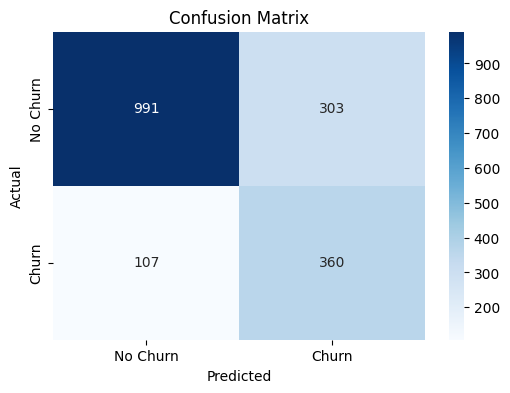

In [30]:
y_pred = pipeline.predict(X_test)

print("\n--- Model Evaluation on Test Set ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [31]:
# plot learning curve
from sklearn.model_selection import learning_curve
def plot_learning_curve(estimator, X, y, cv=5, scoring='f1'):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring,
        n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(6, 3))
    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-validation score')
    plt.title('Learning Curve')
    plt.xlabel('Training Size')
    plt.ylabel(scoring)
    plt.legend(loc='best')
    plt.grid()
    plt.show()

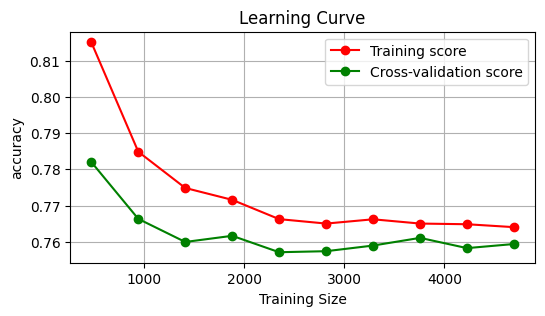

In [32]:
plot_learning_curve(pipeline, X, y, cv=3, scoring='accuracy')

Great Example of how should a ```UNDERFITTING - HIGH BIAS - MODEL``` look like.

However, because of the time restriction, we are going to use this model to continue with the PoC to prove our engineering skills not proving a production level model.

In [33]:
# save the best model
import joblib
joblib.dump(pipeline, "churn_pipeline.pkl")

['churn_pipeline.pkl']

In [34]:
import joblib
svm_model = joblib.load("churn_pipeline.pkl")
svm_model

,steps,"[('preprocessor', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
import pandas as pd
svm_model = joblib.load("churn_pipeline.pkl")

sample_input_pipeline = pd.DataFrame([{
    "gender": 1,
    "Senior_Citizen": 0,
    "Is_Married": 1,
    "Dependents": 0,
    "tenure": 12.0,
    "Phone_Service": 1,
    "Dual": 0,
    "Online_Security": 1,
    "Online_Backup": 0,
    "Device_Protection": 1,
    "Tech_Support": 0,
    "Streaming_TV": 1,
    "Streaming_Movies": 0,
    "Paperless_Billing": 1,
    "Monthly_Charges": 75.5,
    "Total_Charges": 800.0,
    "Internet_Service": "Fiber optic",              # raw categorical
    "Contract": "Two year",                          # raw categorical
    "Payment_Method": "Credit card (automatic)"     # raw categorical
}])

# Predict with the pipeline
prediction = svm_model.predict(sample_input_pipeline)
print("Prediction:", prediction[0])



Prediction: 0
